In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Cấu hình phong cách
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11, 'figure.facecolor': 'white'})

print("Đang tải và xử lý dữ liệu...")
df_raw = pd.read_excel('../data.xlsx', sheet_name='Data')

# Làm sạch tên cột năm
year_cols = [col for col in df_raw.columns if '[YR' in str(col)]
rename_dict = {col: int(str(col).split(' ')[0]) for col in year_cols}
df_raw.rename(columns=rename_dict, inplace=True)
df_raw.replace('..', np.nan, inplace=True)

# Melt
id_vars = ['Country Name', 'Country Code', 'Series Name', 'Series Code']
df_melted = pd.melt(df_raw, id_vars=id_vars, value_vars=list(rename_dict.values()),
                    var_name='Year', value_name='Value')
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

# Lọc Quốc gia
target_countries = [
    'Viet Nam', 'Thailand', 'Indonesia', 'Malaysia', 'Philippines',
    'Singapore', 'Cambodia', 'Lao PDR', 'Myanmar',
    'High income', 'Upper middle income', 'Lower middle income', 'Low income'
]
df_clean = df_melted[df_melted['Country Name'].isin(target_countries)].copy()

# Pivot
df_multi = df_clean.pivot_table(index=['Country Name', 'Year'], columns='Series Code', values='Value').reset_index()

# Từ điển ánh xạ các Mã Series sang Tên dễ gọi
indicators = {
    'NV.IND.TOTL.ZS': 'Ind_GDP', 'EN.GHG.CO2.PC.CE.AR5': 'CO2_PC', 'EN.GHG.CO2.RT.GDP.KD': 'CO2_Intens',
    'EN.ATM.PM25.MC.M3': 'PM25', 'SH.DYN.MORT': 'U5_Mortality', 'SP.DYN.LE00.IN': 'Life_Exp',
    'SL.UEM.TOTL.ZS': 'Unemp_Total', 'SL.EMP.VULN.ZS': 'Vuln_Emp', 'SL.EMP.WORK.ZS': 'Wage_Emp',
    'SL.TLF.CACT.FE.ZS': 'LFPR_Fe', 'SL.TLF.CACT.MA.ZS': 'LFPR_Ma', 'SE.ENR.TERT.FM.ZS': 'Tert_GPI',
    'SG.GEN.PARL.ZS': 'Parl_Fe', 'SL.EMP.SMGT.FE.ZS': 'Mgt_Fe', 'SL.UEM.NEET.FE.ZS': 'NEET_Fe',
    'SP.URB.TOTL.IN.ZS': 'Urb_Pop', 'SP.URB.GROW': 'Urb_Grow', 'EN.POP.SLUM.UR.ZS': 'Slum_Pop',
    'SH.STA.BASS.ZS': 'Sanitation', 'BX.TRF.PWKR.DT.GD.ZS': 'Remittances',
    'GB.XPD.RSDV.GD.ZS': 'RnD', 'TX.VAL.TECH.MF.ZS': 'HighTech', 'HD_HCIP_OVRL_TO': 'HCI',
    'CC.EST': 'CC', 'GE.EST': 'GE', 'VA.EST': 'VA', 'RQ.EST': 'RQ'
}
df_multi.rename(columns=indicators, inplace=True)
print(f"Xử lý thành công! Kích thước ma trận: {df_multi.shape}")

Đang tải và xử lý dữ liệu...


ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [5]:
print("\n--- Phân tích Mục tiêu 1: Thất nghiệp vs Lao động dễ tổn thương ---")

# Chọn quốc gia ASEAN (không lấy income group cho biểu đồ này)
asean_countries = [
    'Viet Nam', 'Thailand', 'Indonesia', 'Malaysia',
    'Philippines', 'Singapore', 'Cambodia', 'Lao PDR', 'Myanmar'
]

df_asean = df_multi[df_multi['Country Name'].isin(asean_countries)].copy()

# Lọc giai đoạn gần đây
df_recent = df_asean[df_asean['Year'] >= 2020].copy()

# Lấy trung bình để giảm nhiễu
df_plot = df_recent.groupby('Country Name')[['Unemp_Total', 'Vuln_Emp']].mean().reset_index()

print(df_plot.head())


--- Phân tích Mục tiêu 1: Thất nghiệp vs Lao động dễ tổn thương ---
Series Code Country Name  Unemp_Total   Vuln_Emp
0               Cambodia     0.264333  52.990540
1              Indonesia     3.565000  50.239178
2                Lao PDR     1.530833  77.042692
3               Malaysia     4.096333  22.200180
4                Myanmar     2.965000  62.860618


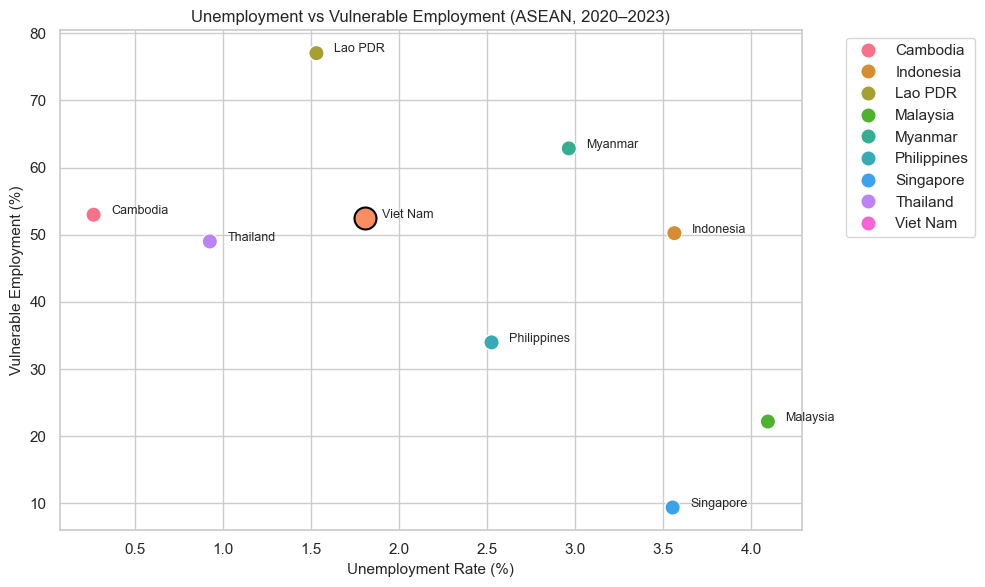

In [6]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_plot,
    x='Unemp_Total',
    y='Vuln_Emp',
    hue='Country Name',
    s=120
)

# Highlight Việt Nam
vn = df_plot[df_plot['Country Name'] == 'Viet Nam']
plt.scatter(
    vn['Unemp_Total'], vn['Vuln_Emp'],
    s=250, edgecolor='black', linewidth=1.5
)

# Annotate tên nước
for i in range(len(df_plot)):
    plt.text(
        df_plot['Unemp_Total'][i] + 0.1,
        df_plot['Vuln_Emp'][i] + 0.1,
        df_plot['Country Name'][i],
        fontsize=9
    )

plt.title("Unemployment vs Vulnerable Employment (ASEAN, 2020–2023)")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Vulnerable Employment (%)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

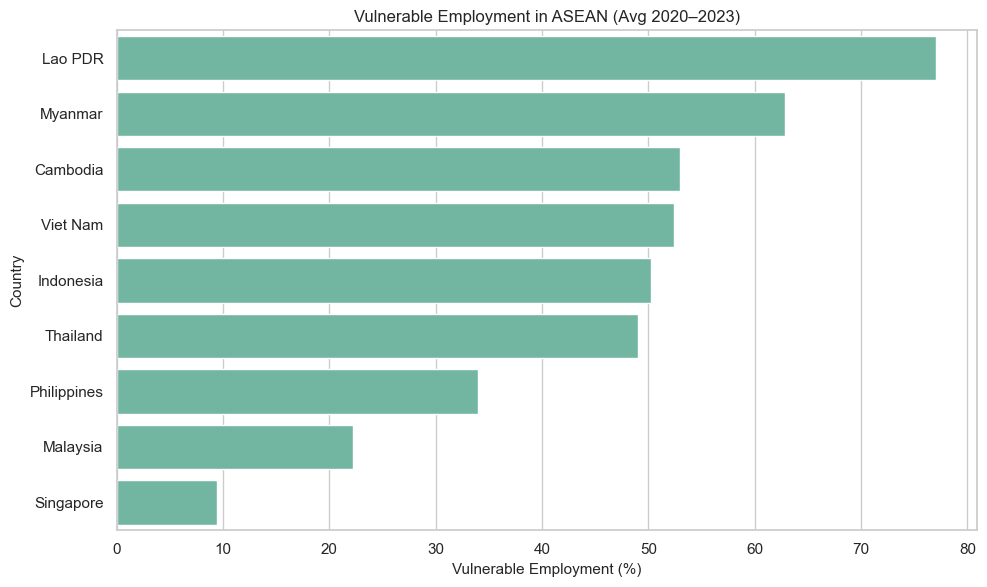

In [7]:
plt.figure(figsize=(10, 6))

df_sorted = df_plot.sort_values(by='Vuln_Emp', ascending=False)

sns.barplot(
    data=df_sorted,
    x='Vuln_Emp',
    y='Country Name'
)

plt.title("Vulnerable Employment in ASEAN (Avg 2020–2023)")
plt.xlabel("Vulnerable Employment (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [8]:
print("\n--- Mục tiêu 2: Xu hướng Việt Nam (2000–2023) ---")

df_vn = df_multi[df_multi['Country Name'] == 'Viet Nam'].copy()

# Lọc giai đoạn
df_vn = df_vn[(df_vn['Year'] >= 2000) & (df_vn['Year'] <= 2023)]

# Sắp xếp theo năm
df_vn = df_vn.sort_values(by='Year')

print(df_vn[['Year', 'Unemp_Total', 'Vuln_Emp']].head())


--- Mục tiêu 2: Xu hướng Việt Nam (2000–2023) ---
Series Code  Year  Unemp_Total   Vuln_Emp
250          2001        2.760  71.178274
251          2002        2.120  71.568136
252          2003        2.250  70.114415
253          2004        2.140  66.366174
254          2005        2.078  65.828571


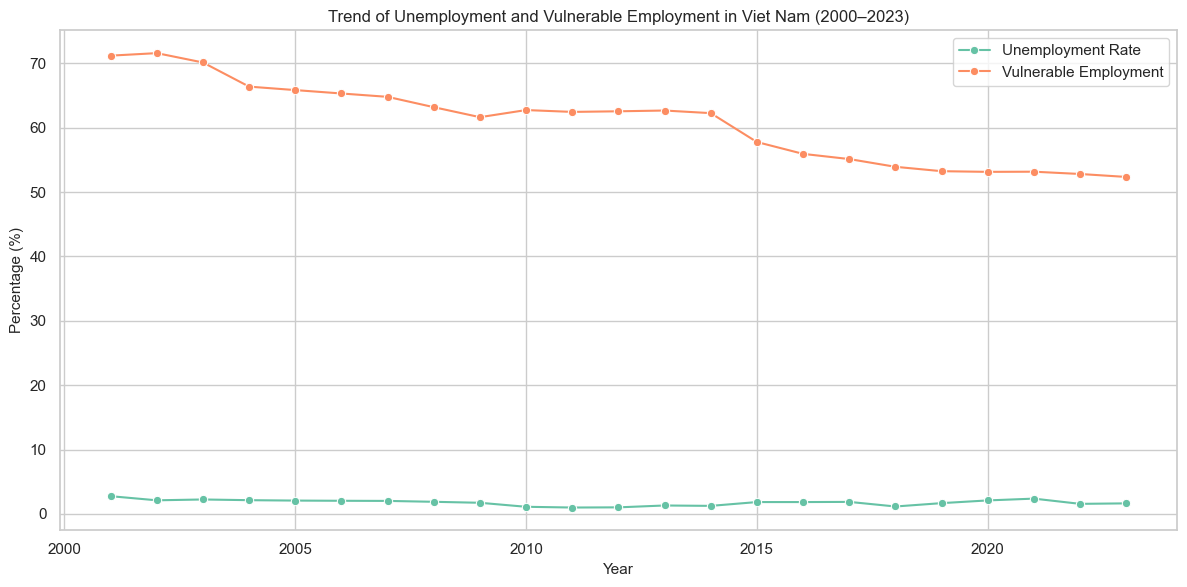

In [13]:
plt.figure(figsize=(12, 6))

# Line Unemployment
sns.lineplot(
    data=df_vn,
    x='Year',
    y='Unemp_Total',
    label='Unemployment Rate',
    marker='o'
)

# Line Vulnerable
sns.lineplot(
    data=df_vn,
    x='Year',
    y='Vuln_Emp',
    label='Vulnerable Employment',
    marker='o'
)

plt.title("Trend of Unemployment and Vulnerable Employment in Viet Nam (2000–2023)")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")


plt.legend()
plt.tight_layout()
plt.show()